# Image Captioning with a Frozen Pretrained ViT-B/16

## Model overview
A pretrained ViT-B/16 encodes each image into visual tokens. The encoder stays frozen, while a cross-attention Transformer decoder learns to generate captions.

## Experiment settings
- Image resolution: 384x384
- Batch size: 4
- Tokenizer: BPE trained on all training captions
- Sequence length: maximum training token count
- Training: fixed number of epochs with no early stopping

## Evaluation
The final section generates validation captions and reports BLEU-4, ROUGE-L, and CIDEr.

## How to run
Run all cells from top to bottom in a fresh Kaggle session after attaching the dataset.

In [1]:
# ============================================================
# 1. Imports, reproducibility, and configuration
# ============================================================

import os
import re
import math
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

# BPE tokenizer support.
try:
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.pre_tokenizers import Whitespace
    from tokenizers.trainers import BpeTrainer
except ImportError as exc:
    raise ImportError(
        "Install the 'tokenizers' package before running the BPE section."
    ) from exc

# Make the data order and parameter initialization reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use a higher resolution than the original 224x224 ViT input.
IMAGE_SIZE = 384

# Keep the batch small because 384x384 images use substantially more GPU memory.
BATCH_SIZE = 4

NUM_WORKERS = 4
# Increased from the 5-epoch fast baseline: the loss curve was still
# falling steeply at epoch 5, so training needs more epochs to converge.
EPOCHS = 10
LEARNING_RATE = 3e-4

# Select the tokenizer experiment: "bpe" or "word".
TOKENIZER_TYPE = "bpe"

# Used only by the word-level tokenizer.
MIN_WORD_FREQUENCY = 2

# Pool every caption file together, then split by UNIQUE IMAGE into a
# fixed validation set and test set; everything else becomes training data.
VALIDATION_IMAGES = 500
TEST_IMAGES = 500

# Set these manually only if automatic dataset discovery fails.
TRAIN_CAPTIONS_FILE = None
VALIDATION_CAPTIONS_FILE = None
IMAGES_DIR = None

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Tokenizer:", TOKENIZER_TYPE)


Device: cuda
GPU: Tesla T4
Image size: 384
Batch size: 4
Tokenizer: bpe


In [2]:
# ============================================================
# 2. Discover dataset files
# ============================================================

INPUT_ROOT = Path('/kaggle/input')
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
# Scan Kaggle input once, then separate image files from annotation candidates.
all_files = [path for path in INPUT_ROOT.rglob('*') if path.is_file()]
image_files = [path for path in all_files if path.suffix.lower() in IMAGE_EXTENSIONS]
text_files = [path for path in all_files if path.suffix.lower() in {'.csv', '.tsv', '.txt'}]

print(f'Images: {len(image_files):,}')
print('Image formats:', Counter(path.suffix.lower() for path in image_files))
print('Caption-file candidates:')
for path in text_files: print(' -', path)

# Prefer clearly named caption files; set the paths manually above if discovery is ambiguous.
caption_candidates = [p for p in text_files if any(key in p.name.lower() for key in ('caption', 'token', 'text', 'description'))]
if TRAIN_CAPTIONS_FILE is None:
    TRAIN_CAPTIONS_FILE = next((p for p in caption_candidates if 'train' in p.name.lower()), None)
if VALIDATION_CAPTIONS_FILE is None:
    VALIDATION_CAPTIONS_FILE = next((p for p in caption_candidates if any(key in p.name.lower() for key in ('val', 'valid', 'dev'))), None)
if TRAIN_CAPTIONS_FILE is None or VALIDATION_CAPTIONS_FILE is None:
    raise FileNotFoundError('Could not identify separate train and validation caption files. Set both paths manually.')
if IMAGES_DIR is None:
    IMAGES_DIR = Path(os.path.commonpath([str(path.parent) for path in image_files]))

print('Selected train captions:', TRAIN_CAPTIONS_FILE)
print('Selected validation captions:', VALIDATION_CAPTIONS_FILE)
print('Image root:', IMAGES_DIR)

Images: 64,143
Image formats: Counter({'.jpg': 64143})
Caption-file candidates:
 - /kaggle/input/datasets/amjadbakri/captioning-dataset/train_captioning.csv
 - /kaggle/input/datasets/amjadbakri/captioning-dataset/val_captioning.csv
Selected train captions: /kaggle/input/datasets/amjadbakri/captioning-dataset/train_captioning.csv
Selected validation captions: /kaggle/input/datasets/amjadbakri/captioning-dataset/val_captioning.csv
Image root: /kaggle/input/datasets/amjadbakri/captioning-dataset


In [3]:
# ============================================================
# 3. Load and clean image-caption pairs
# ============================================================

# Accept common CSV column names, then fall back to parsing simple text annotations.
def load_caption_table(path):
    table = pd.read_csv(path, sep=None, engine='python', on_bad_lines='skip')
    columns = {str(column).strip().lower(): column for column in table.columns}
    image_column = next((columns[key] for key in columns if key in {'image', 'image_name', 'filename', 'file_name', 'img'}), None)
    caption_column = next((columns[key] for key in columns if key in {'caption', 'comment', 'description', 'text', 'sentence'}), None)
    if image_column is not None and caption_column is not None:
        return table[[image_column, caption_column]].rename(columns={image_column: 'image_name', caption_column: 'caption'})

    pairs = []
    for line in Path(path).read_text(encoding='utf-8', errors='ignore').splitlines():
        parts = re.split(r'\t|\s*\|\s*|,(?=\s*[A-Za-z])', line, maxsplit=1)
        if len(parts) == 2 and Path(parts[0].split('#')[0].strip()).suffix.lower() in IMAGE_EXTENSIONS:
            pairs.append((Path(parts[0].split('#')[0].strip()).name, parts[1].strip()))
    if not pairs: raise ValueError('Could not identify image/caption columns. Check the annotation file.')
    return pd.DataFrame(pairs, columns=['image_name', 'caption'])

# Normalize captions before tokenizer training so train and validation text use the same format.
def normalize_caption(text):
    text = re.sub(r"[^a-z0-9' ]", ' ', str(text).lower())
    return re.sub(r'\s+', ' ', text).strip()

# Map annotation filenames to discovered images, then discard rows with missing files.
path_by_name = {path.name: path for path in image_files}
def prepare_caption_table(path, split_name):
    table = load_caption_table(path).dropna().copy()
    table['image_name'] = table['image_name'].map(lambda name: Path(str(name)).name)
    table['caption'] = table['caption'].map(normalize_caption)
    table['image_path'] = table['image_name'].map(path_by_name)
    table = table.dropna(subset=['image_path'])
    table = table[table.caption.str.len() > 0].reset_index(drop=True)
    if table.empty:
        raise ValueError(f'No {split_name} caption records matched images. Check filenames and paths.')
    return table

# Pool BOTH caption files together (same recipe as the pretrained-BLIP
# notebook), then split by UNIQUE IMAGE into a fixed validation set and
# test set. Validation drives checkpoint selection during training; the
# test set is only touched once, for final evaluation.
all_captions = pd.concat(
    [
        prepare_caption_table(TRAIN_CAPTIONS_FILE, 'training'),
        prepare_caption_table(VALIDATION_CAPTIONS_FILE, 'validation'),
    ],
    ignore_index=True,
)

# Remove duplicate image-caption pairs before splitting.
all_captions = all_captions.drop_duplicates(
    ['image_name', 'caption']
).reset_index(drop=True)

# Split must happen at the IMAGE level, not the caption level, so no
# image's captions end up spread across more than one split.
image_names = np.array(sorted(all_captions.image_name.unique()))
if len(image_names) <= VALIDATION_IMAGES + TEST_IMAGES:
    raise ValueError('There must be more images than validation plus test images.')

rng = np.random.default_rng(SEED)
held_out_names = rng.choice(
    image_names, size=VALIDATION_IMAGES + TEST_IMAGES, replace=False
)
validation_names = set(held_out_names[:VALIDATION_IMAGES])
test_names = set(held_out_names[VALIDATION_IMAGES:])

validation_table = all_captions[
    all_captions.image_name.isin(validation_names)
].reset_index(drop=True)

test_table = all_captions[
    all_captions.image_name.isin(test_names)
].reset_index(drop=True)

captions = all_captions[
    ~all_captions.image_name.isin(validation_names | test_names)
].reset_index(drop=True)

train_names = set(captions.image_name)

# Verify the three splits never overlap and together cover every image.
assert train_names.isdisjoint(validation_names)
assert train_names.isdisjoint(test_names)
assert validation_names.isdisjoint(test_names)
assert (
    len(train_names) + len(validation_names) + len(test_names)
    == len(image_names)
)

display(captions.head())
print(f'Train pairs: {len(captions):,}; unique images: {len(train_names):,}')
print(f'Validation pairs: {len(validation_table):,}; unique images: {len(validation_names):,}')
print(f'Test pairs: {len(test_table):,}; unique images: {len(test_names):,}')

,image_name,caption,image_path
0,000000571635.jpg,a bathroom with a toilet sink and shower,/kaggle/input/datasets/amjadbakri/captioning-d...
1,000000301837.jpg,a long empty minimal modern skylit home kitchen,/kaggle/input/datasets/amjadbakri/captioning-d...
2,000000315702.jpg,a bathroom sink with toiletries on the counter,/kaggle/input/datasets/amjadbakri/captioning-d...
3,000000315702.jpg,a bathroom sink and various personal hygiene i...,/kaggle/input/datasets/amjadbakri/captioning-d...
4,000000189634.jpg,this is an open box containing four cucumbers,/kaggle/input/datasets/amjadbakri/captioning-d...


Train pairs: 315,723; unique images: 63,143
Validation pairs: 2,499; unique images: 500
Test pairs: 2,501; unique images: 500


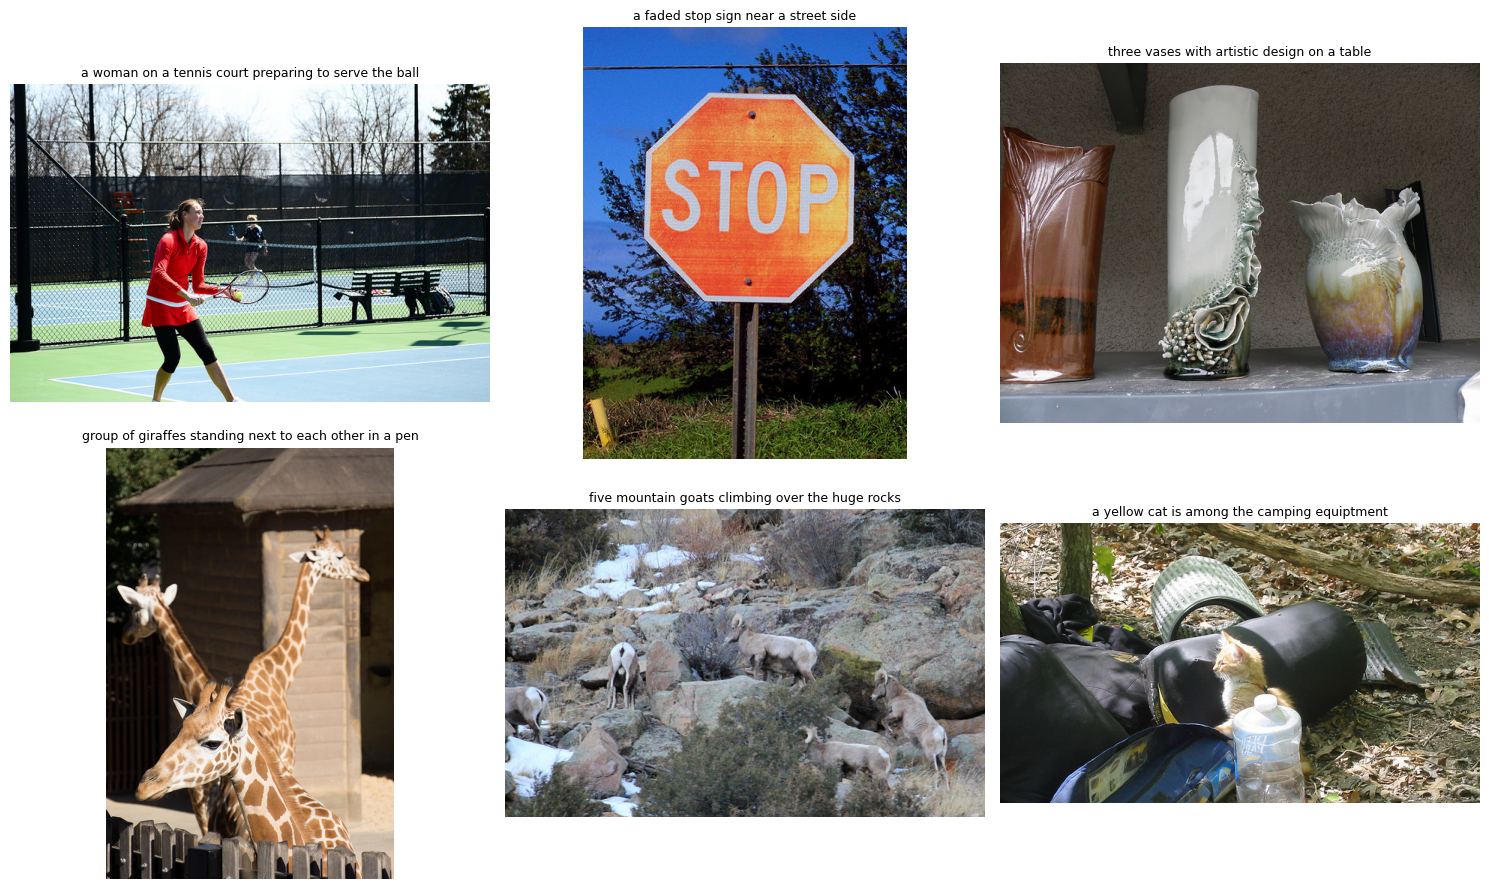

count    315723.000000
mean         10.470121
std           2.400152
min           6.000000
25%           9.000000
50%          10.000000
75%          11.000000
max          50.000000
Name: word_count, dtype: float64
Most common words: [('a', 522325), ('on', 114649), ('of', 109009), ('the', 105510), ('in', 98407), ('with', 82532), ('and', 74844), ('is', 52364), ('man', 38930), ('to', 36463), ('sitting', 28238), ('an', 26593), ('two', 26073), ('at', 23063), ('standing', 22631), ('people', 22091), ('are', 21888), ('next', 19797), ('white', 19447), ('woman', 18018)]


In [4]:
# ============================================================
# 4. Explore image-caption pairs and caption statistics
# ============================================================

samples = captions.sample(min(6, len(captions)), random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, (_, row) in zip(axes.flat, samples.iterrows()):
    axis.imshow(Image.open(row.image_path).convert('RGB'))
    axis.set_title(row.caption, fontsize=9, wrap=True)
    axis.axis('off')
plt.tight_layout()
plt.show()

captions['word_count'] = captions.caption.str.split().map(len)
print(captions.word_count.describe())
print('Most common words:', Counter(' '.join(captions.caption).split()).most_common(20))




Tokenizer type: bpe
Vocabulary size: 17,045
Maximum token length: 53


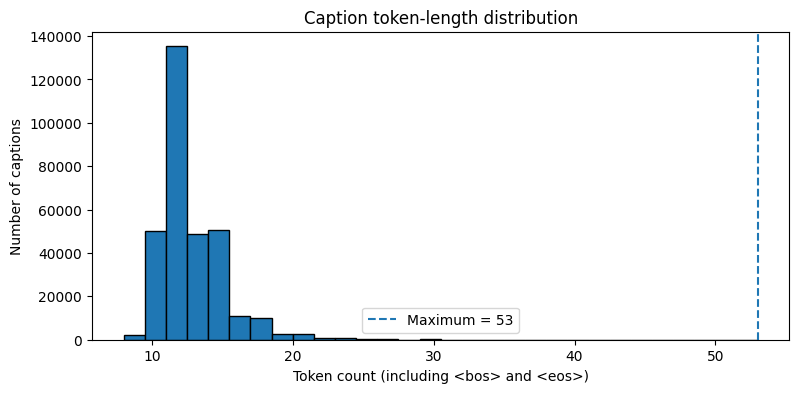

In [5]:
# ============================================================
# 5. Build the tokenizer from 100% of the training captions
# ============================================================

# Keep a dedicated training table because token IDs are added below.
train_table = captions.reset_index(drop=True)

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"


def build_word_tokenizer(captions):
    # Build vocabulary from the complete training corpus.
    word_counts = Counter(
        word for caption in captions for word in caption.split()
    )

    # No fixed MAX_VOCAB_SIZE is used.
    vocabulary_words = [
        word
        for word, count in word_counts.most_common()
        if count >= MIN_WORD_FREQUENCY
    ]

    itos = SPECIAL_TOKENS + vocabulary_words
    stoi = {token: index for index, token in enumerate(itos)}
    return stoi, itos


def build_bpe_tokenizer(captions):
    # Train BPE on every training caption; validation text never affects the vocabulary.
    unique_words = {
        word for caption in captions for word in caption.split()
    }

    # Derive the target vocabulary size from the complete corpus instead
    # of using the old fixed MAX_VOCAB_SIZE = 12000.
    bpe_vocab_size = len(unique_words) + len(SPECIAL_TOKENS)

    tokenizer = Tokenizer(BPE(unk_token=UNK_TOKEN))
    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=bpe_vocab_size,
        min_frequency=MIN_WORD_FREQUENCY,
        special_tokens=SPECIAL_TOKENS
    )

    tokenizer.train_from_iterator(captions, trainer=trainer)

    vocabulary = tokenizer.get_vocab()
    stoi = dict(vocabulary)

    itos = [
        token
        for token, _ in sorted(
            vocabulary.items(),
            key=lambda item: item[1]
        )
    ]

    return tokenizer, stoi, itos


if TOKENIZER_TYPE.lower() == "bpe":
    bpe_tokenizer, stoi, itos = build_bpe_tokenizer(
        train_table["caption"].tolist()
    )

    PAD_ID = stoi[PAD_TOKEN]
    BOS_ID = stoi[BOS_TOKEN]
    EOS_ID = stoi[EOS_TOKEN]
    UNK_ID = stoi[UNK_TOKEN]

    def encode_caption(caption):
        encoding = bpe_tokenizer.encode(caption)
        return [BOS_ID] + encoding.ids + [EOS_ID]

else:
    stoi, itos = build_word_tokenizer(
        train_table["caption"].tolist()
    )

    PAD_ID = stoi[PAD_TOKEN]
    BOS_ID = stoi[BOS_TOKEN]
    EOS_ID = stoi[EOS_TOKEN]
    UNK_ID = stoi[UNK_TOKEN]

    def encode_caption(caption):
        return (
            [BOS_ID]
            + [stoi.get(word, UNK_ID) for word in caption.split()]
            + [EOS_ID]
        )


# Tokenize both splits with the training-only tokenizer.
train_table["token_ids"] = train_table["caption"].map(encode_caption)
validation_table["token_ids"] = validation_table["caption"].map(encode_caption)

# MAX_LENGTH is the maximum number of TOKENS across 100% of
# the training captions. No 95th percentile is used.
token_lengths = train_table["token_ids"].map(len)
MAX_LENGTH = int(token_lengths.max())

print("Tokenizer type:", TOKENIZER_TYPE)
print(f"Vocabulary size: {len(itos):,}")
print(f"Maximum token length: {MAX_LENGTH}")

plt.figure(figsize=(9, 4))
plt.hist(token_lengths, bins=30, edgecolor="black")
plt.axvline(MAX_LENGTH, linestyle="--", label=f"Maximum = {MAX_LENGTH}")
plt.xlabel("Token count (including <bos> and <eos>)")
plt.ylabel("Number of captions")
plt.title("Caption token-length distribution")
plt.legend()
plt.show()


In [6]:
# ============================================================
# 6. Build PyTorch datasets and image transforms
# ============================================================

# Preserve the token_ids columns created by the tokenizer cell.
train_table = train_table.reset_index(drop=True)
validation_table = validation_table.reset_index(drop=True)

# Match ImageNet normalization because the ViT encoder uses ImageNet pretrained weights.
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class ImageCaptionDataset(Dataset):
    def __init__(self, table, transform, max_length, one_caption_per_image=False):
        self.table = table.reset_index(drop=True)
        self.transform = transform
        self.max_length = max_length
        self.one_caption_per_image = one_caption_per_image
        self.epoch = 0
        self.caption_indices_by_image = None

        if self.one_caption_per_image:
            # Group captions once, then use one deterministic caption per image in each epoch.
            self.caption_indices_by_image = [
                group.index.to_list()
                for _, group in self.table.groupby("image_name", sort=False)
            ]

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        if self.one_caption_per_image:
            return len(self.caption_indices_by_image)
        return len(self.table)

    def __getitem__(self, index):
        if self.one_caption_per_image:
            caption_indices = self.caption_indices_by_image[index]
            row_index = caption_indices[(index + self.epoch) % len(caption_indices)]
        else:
            row_index = index
        row = self.table.iloc[row_index]
        image = Image.open(row.image_path).convert('RGB')
        image_tensor = self.transform(image)
        # Pad to a fixed length. If truncation is ever needed, retain the EOS marker.
        token_ids = row["token_ids"]
        if len(token_ids) > self.max_length:
            token_ids = token_ids[:self.max_length - 1] + [EOS_ID]
        token_ids = token_ids + [PAD_ID] * (self.max_length - len(token_ids))
        return image_tensor, torch.tensor(token_ids, dtype=torch.long)

# Use one caption per image per epoch to avoid re-encoding the same frozen ViT features five times.
train_dataset = ImageCaptionDataset(
    train_table,
    image_transform,
    MAX_LENGTH,
    one_caption_per_image=True,
)
validation_dataset = ImageCaptionDataset(validation_table, image_transform, MAX_LENGTH)
# Shuffle only training data; pin memory speeds host-to-GPU transfers on CUDA.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)
image_tensor, token_ids = train_dataset[0]
print('Dataset tuple shapes:', image_tensor.shape, token_ids.shape)
print('Train pairs:', len(train_dataset), '| Validation pairs:', len(validation_dataset))

Dataset tuple shapes: torch.Size([3, 384, 384]) torch.Size([53])
Train pairs: 63143 | Validation pairs: 2499


## 7. Model â€” preserve the pretrained ViT-B/16

The encoder remains **pretrained and frozen**.

At 224—224: 196 patches + 1 CLS token = 197 tokens.

At 384—384: 576 patches + 1 CLS token = 577 tokens.

The original pretrained positional embeddings are interpolated from the 224Ã—224 grid to the 384Ã—384 grid. The ViT weights are not reinitialized.


In [7]:
# ============================================================
# 7. Pretrained ViT-B/16 + cross-attention decoder
# ============================================================

MODEL_DIM = 768
NUM_HEADS = 12
DECODER_LAYERS = 6
DROPOUT = 0.1


def interpolate_vit_position_embeddings(position_embedding, new_image_size, patch_size=16):
    # Separate the CLS embedding from the patch embeddings.
    cls_embedding = position_embedding[:, :1]
    patch_embeddings = position_embedding[:, 1:]

    old_grid = int(patch_embeddings.shape[1] ** 0.5)
    new_grid = new_image_size // patch_size

    patch_embeddings = patch_embeddings.reshape(
        1, old_grid, old_grid, -1
    ).permute(0, 3, 1, 2)

    # Interpolate the pretrained 2D positional grid.
    patch_embeddings = torch.nn.functional.interpolate(
        patch_embeddings,
        size=(new_grid, new_grid),
        mode="bicubic",
        align_corners=False
    )

    patch_embeddings = patch_embeddings.permute(
        0, 2, 3, 1
    ).reshape(1, new_grid * new_grid, -1)

    return torch.cat([cls_embedding, patch_embeddings], dim=1)


class CrossAttentionDecoderLayer(nn.Module):
    # One causal self-attention + image cross-attention block.
    def __init__(self, dimension, heads, dropout):
        super().__init__()

        self.self_norm = nn.LayerNorm(dimension)
        self.cross_norm = nn.LayerNorm(dimension)
        self.ffn_norm = nn.LayerNorm(dimension)

        self.self_attention = nn.MultiheadAttention(
            dimension, heads, dropout=dropout, batch_first=True
        )
        self.cross_attention = nn.MultiheadAttention(
            dimension, heads, dropout=dropout, batch_first=True
        )

        self.feed_forward = nn.Sequential(
            nn.Linear(dimension, 4 * dimension),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dimension, dimension)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens, visual_tokens, causal_mask, key_padding_mask):
        # Prevent the decoder from looking at future caption tokens.
        x = self.self_norm(tokens)
        attended, _ = self.self_attention(
            x, x, x,
            attn_mask=causal_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )
        tokens = tokens + self.dropout(attended)

        # Let caption tokens attend to visual tokens.
        x = self.cross_norm(tokens)
        attended, _ = self.cross_attention(
            x, visual_tokens, visual_tokens, need_weights=False
        )
        tokens = tokens + self.dropout(attended)

        # Feed-forward transformation.
        return tokens + self.dropout(
            self.feed_forward(self.ffn_norm(tokens))
        )


class ViTCrossAttentionCaptioner(nn.Module):
    def __init__(self, vocab_size, max_length):
        super().__init__()

        # Load the original pretrained ViT-B/16 weights.
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        print("Loaded pretrained ViT-B/16 weights.")

        # Remove the ImageNet classification head.
        self.vit.heads = nn.Identity()

        # Interpolate the pretrained 14x14 positional grid to the 24x24 grid used at 384x384.
        with torch.no_grad():
            interpolated_pos = interpolate_vit_position_embeddings(
                self.vit.encoder.pos_embedding,
                new_image_size=IMAGE_SIZE,
                patch_size=16
            )

            self.vit.encoder.pos_embedding = nn.Parameter(
                interpolated_pos,
                requires_grad=False
            )

        self.vit.image_size = IMAGE_SIZE

        # Preserve pretrained visual features: gradients flow only through the caption decoder.
        for parameter in self.vit.parameters():
            parameter.requires_grad = False

        # Trainable caption decoder.
        self.token_embedding = nn.Embedding(
            vocab_size, MODEL_DIM, padding_idx=PAD_ID
        )
        self.position_embedding = nn.Embedding(
            max_length, MODEL_DIM
        )

        self.decoder = nn.ModuleList([
            CrossAttentionDecoderLayer(
                MODEL_DIM, NUM_HEADS, DROPOUT
            )
            for _ in range(DECODER_LAYERS)
        ])

        self.final_norm = nn.LayerNorm(MODEL_DIM)

        # Tie input and output token embeddings.
        self.output_head = nn.Linear(
            MODEL_DIM, vocab_size, bias=False
        )
        self.output_head.weight = self.token_embedding.weight

        self.max_length = max_length

        # Causal mask for decoder self-attention.
        mask = torch.triu(
            torch.ones(
                max_length - 1,
                max_length - 1,
                dtype=torch.bool
            ),
            diagonal=1
        )

        self.register_buffer(
            "causal_mask", mask, persistent=False
        )

    # Image encoding never needs gradients because the ViT is frozen.
    @torch.no_grad()
    def encode_images(self, images):
        # Extract visual tokens using the frozen pretrained ViT.
        patches = self.vit._process_input(images)
        class_token = self.vit.class_token.expand(
            images.size(0), -1, -1
        )

        return self.vit.encoder(
            torch.cat([class_token, patches], dim=1)
        )

    # Decode caption tokens while cross-attending to a precomputed image representation.
    def decode_tokens(self, visual_tokens, input_ids):
        positions = torch.arange(
            input_ids.size(1),
            device=input_ids.device
        ).unsqueeze(0)

        tokens = (
            self.token_embedding(input_ids)
            + self.position_embedding(positions)
        )

        length = input_ids.size(1)
        padding_mask = input_ids.eq(PAD_ID)

        for layer in self.decoder:
            tokens = layer(
                tokens,
                visual_tokens,
                self.causal_mask[:length, :length],
                padding_mask
            )

        return self.output_head(self.final_norm(tokens))

    def forward(self, images, input_ids):
        return self.decode_tokens(self.encode_images(images), input_ids)


model = ViTCrossAttentionCaptioner(
    vocab_size=len(itos),
    max_length=MAX_LENGTH
).to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters())
trainable_count = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {parameter_count:,}")
print(f"Trainable parameters: {trainable_count:,}")
print(
    "Pretrained ViT frozen:",
    all(not p.requires_grad for p in model.vit.parameters())
)
print(
    "ViT positional embedding shape:",
    tuple(model.vit.encoder.pos_embedding.shape)
)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 239MB/s] 


Loaded pretrained ViT-B/16 weights.
Total parameters: 155,933,952
Trainable parameters: 69,843,456
Pretrained ViT frozen: True
ViT positional embedding shape: (1, 577, 768)


Epoch 01/10 | Train:   0%|          | 0/15786 [00:00<?, ?it/s]

Epoch 01/10 | Valid:   0%|          | 0/625 [00:00<?, ?it/s]


Epoch 01/10 | train CE: 5.7789 | valid CE: 3.4872
Best checkpoint saved.


Epoch 02/10 | Train:   0%|          | 0/15786 [00:00<?, ?it/s]

Epoch 02/10 | Valid:   0%|          | 0/625 [00:00<?, ?it/s]

...


Epoch 09/10 | train CE: 2.4354 | valid CE: 2.5078
Best checkpoint saved.


Epoch 10/10 | Train:   0%|          | 0/15786 [00:00<?, ?it/s]

Epoch 10/10 | Valid:   0%|          | 0/625 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0e3a472a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0e3a472a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Epoch 10/10 | train CE: 2.3891 | valid CE: 2.4957
Best checkpoint saved.
Training completed.
Final checkpoint saved.


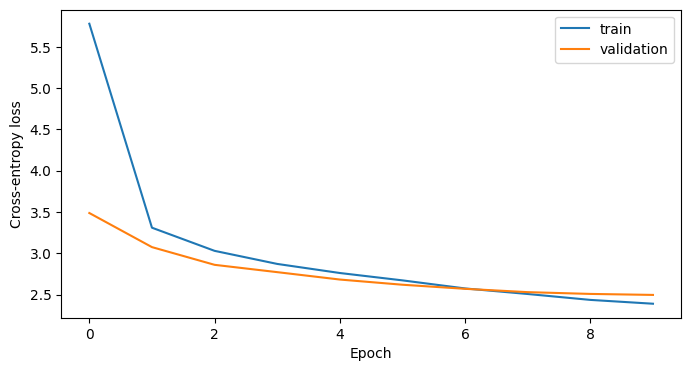

In [8]:
# ============================================================
# 8. Training â€” no early stopping
# ============================================================
from tqdm.auto import tqdm

# Optimize decoder parameters only; the pretrained ViT parameters remain frozen.
optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

def run_epoch(loader, training=True, epoch=1):
    model.train(training)
    model.vit.eval()  # frozen encoder must remain deterministic
    running_loss, token_count = 0.0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    progress = tqdm(loader, desc=f"Epoch {epoch:02d}/{EPOCHS} | {'Train' if training else 'Valid'}", leave=True, dynamic_ncols=True)
    with context:
        for images, captions_batch in progress:
            images = images.to(DEVICE, non_blocking=True)
            captions_batch = captions_batch.to(DEVICE, non_blocking=True)
            # Teacher forcing: predict token t+1 from all preceding ground-truth tokens.
            decoder_input, targets = captions_batch[:, :-1], captions_batch[:, 1:]
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
                logits = model(images, decoder_input)
                loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            # Clip gradients to keep decoder updates stable at the chosen learning rate.
            if training:
                scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), 1.0)
                scaler.step(optimizer); scaler.update()
            count = targets.ne(PAD_ID).sum().item()
            running_loss += loss.item() * count; token_count += count
            progress.set_postfix(loss=f'{loss.item():.4f}', avg=f'{running_loss / max(token_count, 1):.4f}', lr=f"{optimizer.param_groups[0]['lr']:.2e}")
    return running_loss / max(token_count, 1)

history = {'train_loss': [], 'validation_loss': []}
best_loss = float('inf')
for epoch in range(1, EPOCHS + 1):
    # Rotate the selected caption for every image between epochs.
    train_dataset.set_epoch(epoch - 1)
    train_loss = run_epoch(train_loader, training=True, epoch=epoch)
    validation_loss = run_epoch(validation_loader, training=False, epoch=epoch)
    scheduler.step()
    history['train_loss'].append(train_loss); history['validation_loss'].append(validation_loss)
    print(f'\nEpoch {epoch:02d}/{EPOCHS} | train CE: {train_loss:.4f} | valid CE: {validation_loss:.4f}')
    # Keep the best validation checkpoint while still completing every requested epoch.
    if validation_loss < best_loss:
        best_loss = validation_loss

        torch.save(
            {
                'model_state': model.state_dict(),
                'stoi': stoi,
                'itos': itos,
                'max_length': MAX_LENGTH,
                'tokenizer_type': TOKENIZER_TYPE,
                'image_size': IMAGE_SIZE,
                'bpe_tokenizer_json': bpe_tokenizer.to_str() if TOKENIZER_TYPE.lower() == 'bpe' else None
            },
            '/kaggle/working/best_vit_captioner.pt'
        )

        print('Best checkpoint saved.')

# Also save the final epoch, which is useful for comparing best-vs-final behavior.
torch.save(
    {
        'model_state': model.state_dict(),
        'stoi': stoi,
        'itos': itos,
        'max_length': MAX_LENGTH,
        'tokenizer_type': TOKENIZER_TYPE,
        'image_size': IMAGE_SIZE,
        'bpe_tokenizer_json': bpe_tokenizer.to_str() if TOKENIZER_TYPE.lower() == 'bpe' else None
    },
    '/kaggle/working/final_vit_captioner.pt'
)

print('Training completed.')
print('Final checkpoint saved.')


plt.figure(figsize=(8, 4)); plt.plot(history['train_loss'], label='train'); plt.plot(history['validation_loss'], label='validation')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.legend(); plt.show()

Caption generation:   0%|          | 0/500 [00:00<?, ?it/s]

Test images: 500
Corpus BLEU-4: 0.2825
ROUGE-L F1: 0.5228
CIDEr: 1.1600


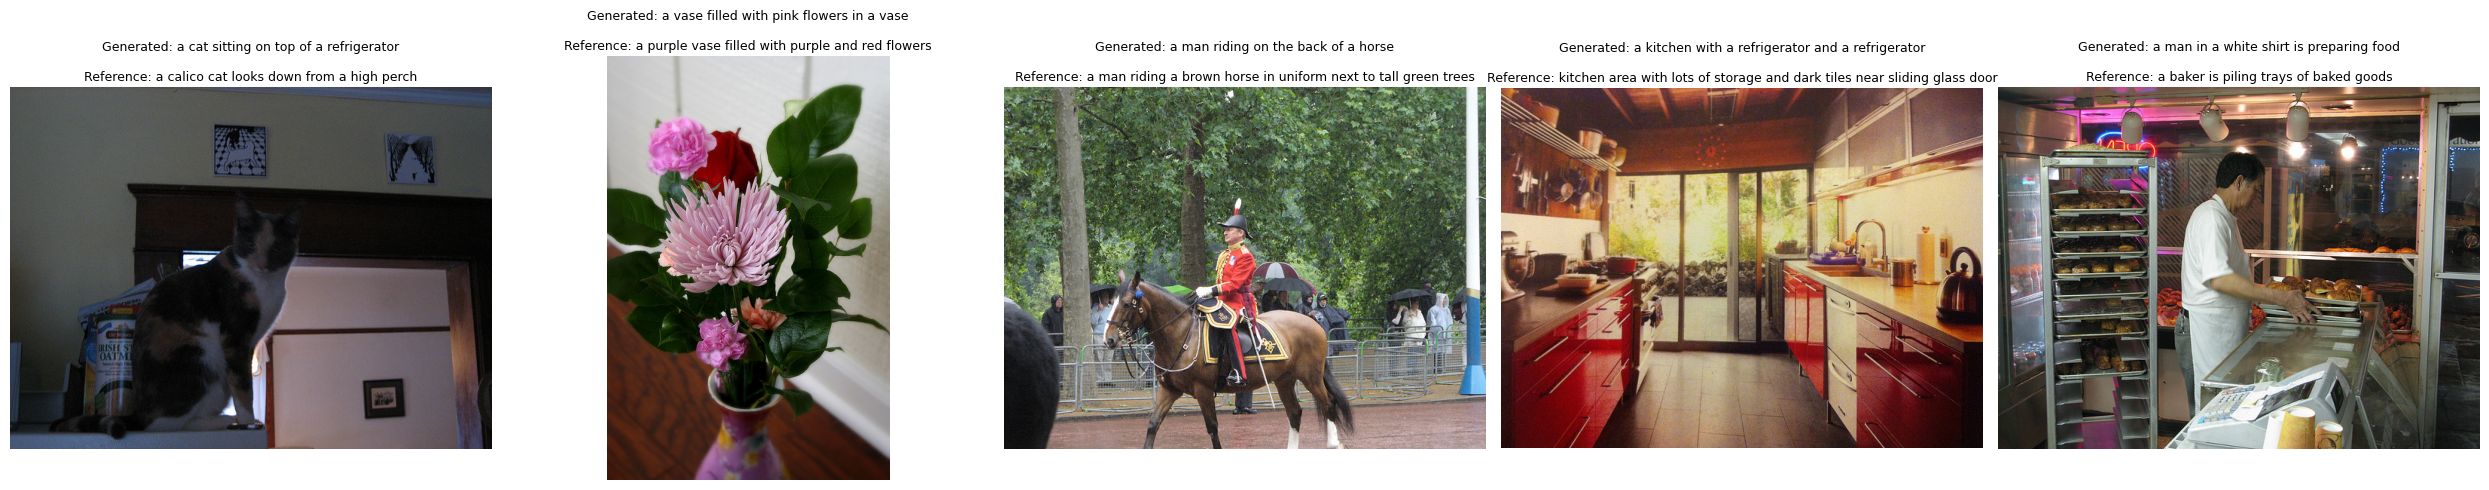

Saved best checkpoint: /kaggle/working/best_vit_captioner.pt


In [9]:
# ============================================================
# 9. Generate captions and evaluate BLEU-4, ROUGE-L, and CIDEr
# ============================================================

checkpoint = torch.load('/kaggle/working/best_vit_captioner.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state']); model.eval()

# Restore the exact BPE model so subword IDs decode into normal text.
CHECKPOINT_TOKENIZER_TYPE = checkpoint['tokenizer_type'].lower()
if CHECKPOINT_TOKENIZER_TYPE == 'bpe':
    bpe_tokenizer = Tokenizer.from_str(checkpoint['bpe_tokenizer_json'])

# Convert model token IDs back to normal text before computing word-level BLEU.
def decode_caption(token_ids):
    if CHECKPOINT_TOKENIZER_TYPE == 'bpe':
        return bpe_tokenizer.decode(token_ids, skip_special_tokens=True)
    return ' '.join(itos[token] for token in token_ids if token not in {PAD_ID, BOS_ID, EOS_ID})

# Greedy autoregressive decoding: generate one token at a time until EOS or MAX_LENGTH.
@torch.no_grad()
def generate_caption(image_tensor, temperature=1.0):
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    visual_tokens = model.encode_images(image_tensor)
    generated = [BOS_ID]
    for _ in range(MAX_LENGTH - 1):
        input_ids = torch.tensor([generated], device=DEVICE)
        logits = model.decode_tokens(visual_tokens, input_ids)[:, -1]
        next_token = int(torch.argmax(logits / temperature, dim=-1).item())
        if next_token == EOS_ID: break
        generated.append(next_token)
    return decode_caption(generated[1:])

def ngrams(tokens, n): return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
# Compute multi-reference corpus BLEU-4 with add-one smoothing for short captions.
def corpus_bleu(predictions, references, max_n=4):
    clipped, totals = [0] * max_n, [0] * max_n
    pred_length, ref_length = 0, 0
    for prediction, refs in zip(predictions, references):
        pred_tokens, ref_tokens = prediction.split(), [ref.split() for ref in refs]
        pred_length += len(pred_tokens)
        ref_length += min((len(ref) for ref in ref_tokens), key=lambda length: abs(length - len(pred_tokens)))
        for n in range(1, max_n + 1):
            counts = ngrams(pred_tokens, n); totals[n - 1] += sum(counts.values())
            max_ref_counts = Counter()
            for ref in ref_tokens:
                for gram, count in ngrams(ref, n).items(): max_ref_counts[gram] = max(max_ref_counts[gram], count)
            clipped[n - 1] += sum(min(count, max_ref_counts[gram]) for gram, count in counts.items())
    precisions = [(clipped[i] + 1) / (totals[i] + 1) for i in range(max_n)]  # add-one smoothing
    brevity_penalty = min(1.0, math.exp(1 - ref_length / max(pred_length, 1)))
    return brevity_penalty * math.exp(sum(math.log(p) for p in precisions) / max_n)

# ROUGE-L measures the longest shared word sequence and rewards sentence-level overlap.
def lcs_length(first_tokens, second_tokens):
    previous_row = [0] * (len(second_tokens) + 1)
    for first_token in first_tokens:
        current_row = [0]
        for column, second_token in enumerate(second_tokens, start=1):
            if first_token == second_token:
                current_row.append(previous_row[column - 1] + 1)
            else:
                current_row.append(max(previous_row[column], current_row[-1]))
        previous_row = current_row
    return previous_row[-1]

def rouge_l_f1(prediction, reference):
    prediction_tokens, reference_tokens = prediction.split(), reference.split()
    if not prediction_tokens or not reference_tokens:
        return 0.0
    lcs = lcs_length(prediction_tokens, reference_tokens)
    precision = lcs / len(prediction_tokens)
    recall = lcs / len(reference_tokens)
    return 2 * precision * recall / max(precision + recall, 1e-12)

def corpus_rouge_l(predictions, references):
    # Use the best matching reference for each generated caption.
    return np.mean([max(rouge_l_f1(prediction, reference) for reference in refs) for prediction, refs in zip(predictions, references)])

# CIDEr uses TF-IDF weighted n-gram cosine similarity across all references.
def tfidf_vector(tokens, n, document_frequency, document_count):
    counts = ngrams(tokens, n)
    total = max(sum(counts.values()), 1)
    return {gram: (count / total) * math.log((document_count + 1) / (document_frequency.get(gram, 0) + 1)) for gram, count in counts.items()}

def cosine_similarity(first_vector, second_vector):
    numerator = sum(value * second_vector.get(key, 0.0) for key, value in first_vector.items())
    first_norm = math.sqrt(sum(value ** 2 for value in first_vector.values()))
    second_norm = math.sqrt(sum(value ** 2 for value in second_vector.values()))
    return numerator / max(first_norm * second_norm, 1e-12)

def corpus_cider(predictions, references, max_n=4):
    # Document frequency is image-level, so repeated captions for one image count once.
    document_frequency = [Counter() for _ in range(max_n)]
    for refs in references:
        for n in range(1, max_n + 1):
            unique_ngrams = {gram for reference in refs for gram in ngrams(reference.split(), n)}
            document_frequency[n - 1].update(unique_ngrams)

    document_count = len(references)
    image_scores = []
    for prediction, refs in zip(predictions, references):
        scores_by_order = []
        for n in range(1, max_n + 1):
            prediction_vector = tfidf_vector(prediction.split(), n, document_frequency[n - 1], document_count)
            reference_scores = [
                cosine_similarity(prediction_vector, tfidf_vector(reference.split(), n, document_frequency[n - 1], document_count))
                for reference in refs
            ]
            scores_by_order.append(np.mean(reference_scores))
        image_scores.append(np.mean(scores_by_order))
    return 10 * float(np.mean(image_scores))

# Final metrics are reported on the held-out TEST set (never touched
# during training or checkpoint selection), not on the validation set.
# Set this to None to evaluate every test image instead of a subsample.
EVALUATION_IMAGES = None
# Keep every reference caption for each image, as required by multi-reference BLEU.
references_by_image = test_table.groupby('image_name').caption.apply(list)
evaluation_names = references_by_image.index
if EVALUATION_IMAGES is not None:
    evaluation_names = references_by_image.index.to_series().sample(min(EVALUATION_IMAGES, len(references_by_image)), random_state=SEED).index
evaluation_rows = test_table.drop_duplicates('image_name').set_index('image_name').loc[evaluation_names]
predictions = [generate_caption(image_transform(Image.open(row.image_path).convert('RGB'))) for _, row in tqdm(evaluation_rows.iterrows(), total=len(evaluation_rows), desc='Caption generation')]
evaluation_references = [references_by_image[name] for name in evaluation_names]
bleu4 = corpus_bleu(predictions, evaluation_references)
rouge_l = corpus_rouge_l(predictions, evaluation_references)
cider = corpus_cider(predictions, evaluation_references)
print(f'Test images: {len(evaluation_rows):,}')
print(f'Corpus BLEU-4: {bleu4:.4f}')
print(f'ROUGE-L F1: {rouge_l:.4f}')
print(f'CIDEr: {cider:.4f}')

shown = evaluation_rows.sample(min(5, len(evaluation_rows)), random_state=SEED)
fig, axes = plt.subplots(1, len(shown), figsize=(5 * len(shown), 5)); axes = np.atleast_1d(axes)
for axis, (name, row) in zip(axes, shown.iterrows()):
    image = Image.open(row.image_path).convert('RGB')
    prediction = predictions[list(evaluation_rows.index).index(name)]
    axis.imshow(image)
    axis.set_title(f'Generated: {prediction}\n\nReference: {references_by_image[name][0]}', fontsize=9, wrap=True)
    axis.axis('off')
plt.tight_layout(); plt.show()
print('Saved best checkpoint: /kaggle/working/best_vit_captioner.pt')